## Introducción

En estos ejercicios vamos a trabajar con  datasets que representan el conjunto de personajes de Marvel en sus cómics con características de cada uno de ellos.

Las columnas del dataframe significan lo siguiente:

1. `page_id`: Identificador único de la página del personaje dentro de la wikia.
2. `name`: Nombre del personaje.
3. `urlslug`: URL única dentro de la wikia que lleva a la página del personaje.
4. `ID`: Estado de identidad del personaje (Identidad secreta, pública, o sin identidad dual en Marvel).
5. `ALIGN`: Alineación del personaje (Bueno, Malo o Neutral).
6. `EYE`: Color de ojos del personaje.
7. `HAIR`: Color de cabello del personaje.
8. `SEX`: Sexo del personaje (e.g. Masculino, Femenino, etc.).
9. `GSM`: Indica si el personaje pertenece a una minoría de género o sexual (e.g. Homosexual, Bisexual).
10. `ALIVE`: Indica si el personaje está vivo o fallecido.
11. `APPEARANCES`: Número de apariciones del personaje en cómics (al 2 de septiembre de 2014; el número puede estar desactualizado).
12. `FIRST APPEARANCE`: Mes y año de la primera aparición del personaje en un cómic, si está disponible.
13. `YEAR`: Año de la primera aparición del personaje en un cómic, si está disponible.



# Parte 1: Extracción de Datos

Concatena todas las fuentes en un solo Dataset , añade para cada fuente una columna , que indique el origen, a fin de que cuando se concatenen poder tener trazabilidad sobre el origen de donde vino el dato. Para MongoDB usa Mongo Compass


In [3]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd
df_txt=pd.read_csv("fuentes marvel/marvel_characters.txt", sep=";")
df_xlsx=pd.read_excel("fuentes marvel/marvel_characters.xlsx")
df_json=pd.read_json("fuentes marvel/marvel_api_response.json")
df_mongo=pd.read_json("fuentes marvel/Marvel.marvel.json")


df_txt["fuente"]="TXT"
df_xlsx["fuente"]="XLSX"
df_json["fuente"]="JSON"
df_mongo["fuente"]="MONGODB"


df= pd.concat([df_txt,df_xlsx,df_json,df_mongo], ignore_index=True)
print(df.shape)
df.head()



(65504, 30)


,ID,Name,URL,Identity,Alignment,Eyes,Hair,Sex,GSM,Status,...,SEX,ALIVE,APPEARANCES,FIRST APPEARANCE,status,code,message,total_records,data,_id
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,NaN,Living Characters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,NaN,Living Characters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1868,"Iron Man (Anthony \""Tony\"" Stark)",\/Iron_Man_(Anthony_%22Tony%22_Stark),Public Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2460,Thor (Thor Odinson),\/Thor_(Thor_Odinson),No Dual Identity,Good Characters,Blue Eyes,Blond Hair,Male Characters,NaN,Living Characters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Parte 2: Análisis Exploratorio y Limpieza de Datos

En esta sección el estudiante debe realizar el análisis exploratorio de datos (EDA), se detectarán outliers, se limpiará el dataset y se responderán preguntas sobre los datos.


## 2.1 EDA Inicial

Se realiza un análisis exploratorio inicial del dataset para comprender su estructura, tipos de datos, cantidad de valores nulos y estadísticas descriptivas básicas.


In [13]:
df.shape
df.dtypes
df.isnull().sum()
df.describe()
df.head()

,ID,Name,URL,Identity,Alignment,Eyes,Hair,Sex,GSM,Status,...,SEX,ALIVE,APPEARANCES,FIRST APPEARANCE,status,code,message,total_records,data,_id
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,NaN,Living Characters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,NaN,Living Characters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1868,"Iron Man (Anthony \""Tony\"" Stark)",\/Iron_Man_(Anthony_%22Tony%22_Stark),Public Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2460,Thor (Thor Odinson),\/Thor_(Thor_Odinson),No Dual Identity,Good Characters,Blue Eyes,Blond Hair,Male Characters,NaN,Living Characters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Gráfico 1: Distribución por Alineación (ALIGN)

Visualiza cuántos personajes hay de cada tipo de alineación (Bueno, Malo, Neutral, etc.).


In [22]:
%pip install matplotlib



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


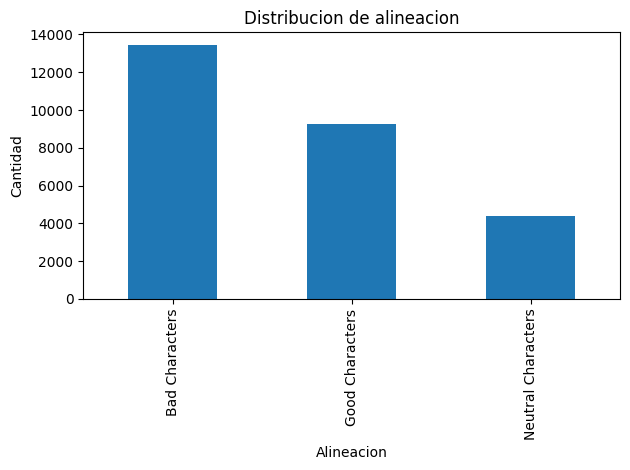

In [24]:
import matplotlib.pyplot as plt
df["ALIGN"].value_counts().plot(kind="bar")
plt.title("Distribucion de alineacion")
plt.xlabel("Alineacion")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

## 2.2 Cálculo de Outliers




In [25]:

Q1 = df["APPEARANCES"].quantile(0.25)
Q3 = df["APPEARANCES"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df["APPEARANCES"] < limite_inferior) | (df["APPEARANCES"] > limite_superior)]
print(f"Cantidad de outliers: {len(outliers)}")

Cantidad de outliers: 3876


### Gráfico 3: Diagrama BoxPlot 

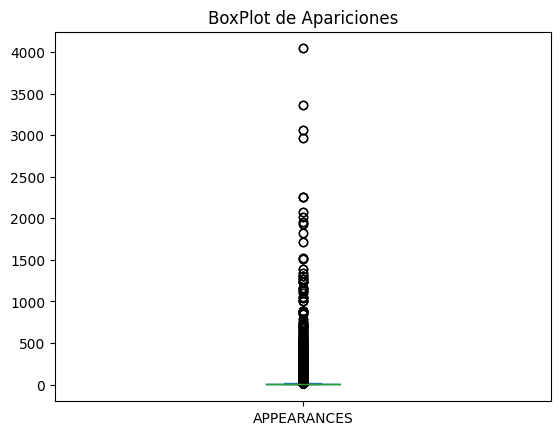

In [29]:
df["APPEARANCES"].plot(kind="box")
plt.title("BoxPlot de Apariciones")
plt.show()

### Gráfico 4: Diagrama de densidad de núcleo (KDE)

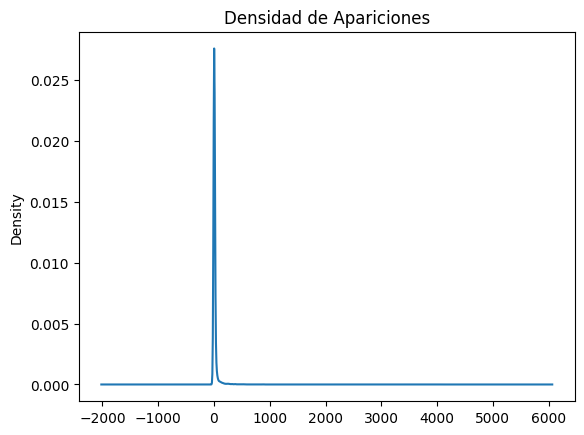

In [34]:
df["APPEARANCES"].plot(kind="kde")
plt.title("Densidad de Apariciones")
plt.show()

## 2.3 Limpieza de Datos

Se debe aplicar los siguientes pasos de limpieza:

- **Eliminar duplicados** exactos del dataset.
- **Imputar valores nulos** en columnas categóricas con `'Desconocido'`.
- **Imputar valores nulos** en columnas numéricas con la **mediana** de la columna.


In [ ]:
import numpy as np


for col in df.columns:
    df[col] = df[col].apply(lambda x: str(x) if isinstance(x, (dict, list)) else x)


df = df.drop_duplicates()


columnas_texto = df.select_dtypes(include="object").columns
for col in columnas_texto:
    df[col] = df[col].fillna("Desconocido")


columnas_numericas = df.select_dtypes(include="number").columns
for col in columnas_numericas:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

C:\Users\ariel\AppData\Local\Temp\ipykernel_4576\4157018662.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_texto = df.select_dtypes(include="object").columns


ID                      0
Name                    0
URL                     0
Identity                0
Alignment               0
Eyes                    0
Hair                    0
Sex                     0
GSM                     0
Status                  0
Appearances             0
First_Appearance    65504
Year                    0
fuente                  0
page_id                 0
name                    0
urlslug                 0
ALIGN                   0
EYE                     0
HAIR                    0
SEX                     0
ALIVE                   0
APPEARANCES             0
FIRST APPEARANCE        0
status                  0
code                    0
message                 0
total_records           0
data                    0
_id                     0
dtype: int64


Consulta y responde, para imputar valores nulos en columnas numericas, cuando es recomendable hacerlo con la media, la mediana, la moda o talvez existen alguna otra técnica?. Responde para cada caso cuando es recomendable

## 2.4 EDA PROFUNDO

Ejercicio 1. Comparación de personajes por década de creación  
Crea una columna de décadas a partir de YEAR.  
Cuenta cuántos personajes fueron creados en cada década.  
Identifica las décadas con mayor número de personajes.  
Realiza una breve interpretación de la evolución de creación de personajes a lo largo del tiempo.  



In [46]:
df["decada"] = (df["Year"] // 10) * 10

conteo_decadas = df.groupby("decada").size().reset_index(name="cantidad")
print(conteo_decadas)

   decada  cantidad
0  1930.0       207
1  1940.0      4323
2  1950.0       906
3  1960.0      3918
4  1970.0      6702
5  1980.0      7275
6  1990.0     29792
7  2000.0      9258
8  2010.0      3123


## 2.5 Preguntas

Responde las siguientes preguntas utilizando el dataset limpio:

1. ¿Cuántos personajes están vivos y cuántos han fallecido?
2. ¿Cuál es el color de cabello más común entre los personajes buenos?
3. ¿Qué porcentaje de personajes tiene identidad secreta?
4. ¿Cuál fue el año en que se crearon más personajes?


In [36]:

print(df["ALIVE"].value_counts())

ALIVE
Living Characters      25216
Deceased Characters     7530
Name: count, dtype: int64


In [37]:
buenos = df[df["ALIGN"] == "Good Characters"]
print(buenos["HAIR"].value_counts().head(1))

HAIR
Black Hair    2292
Name: count, dtype: int64


In [38]:
total = len(df)
secretos = len(df[df["ID"] == "Secret Identity"])
print(f"{(secretos / total) * 100:.2f}%")

19.16%


In [47]:
print(df["Year"].value_counts().head(1))

Year
1990.0    19892
Name: count, dtype: int64


# Parte 3: Visualización de Datos(COMUNICACION DE INFORMACIÓN)


### EJERCICIO 1. Gráfico de tendencia: Evolución de la cantidad de personajes creados por año

- Analiza la cantidad de personajes creados cada año (YEAR).
- Crea un gráfico de línea que muestre la evolución del número de personajes creados a lo largo del tiempo.
- Realiza una interpretación del gráfico


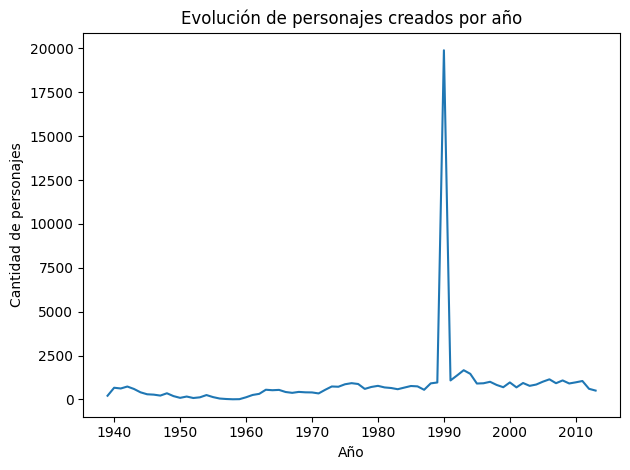

In [49]:
personajes_por_año = df.groupby("Year").size()

personajes_por_año.plot(kind="line")
plt.title("Evolución de personajes creados por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de personajes")
plt.tight_layout()
plt.show()

Se observa un crecimiento sostenido en la creación de personajes desde los años 60, alcanzando su pico máximo en los años 90. A partir del 2000 la cantidad disminuye, posiblemente porque el dataset tiene datos hasta 2014

### EJERCICIO 2. Mapa de calor: Relación entre alineación y estado vivo/fallecido

- Analiza la relación entre la alineación del personaje (ALIGN) y su estado (ALIVE).
- Muestra un mapa de calor que cuente cuántos personajes de cada tipo (Bueno, Malo, Neutral) están vivos o fallecidos.
- Saca una conclusión del gráfico.


Los personajes buenos son los más numerosos y también los que más sobreviven. Los personajes malos tienen una tasa de fallecimiento mayor proporcionalmente, lo que podría reflejar los desenlaces típicos de los cómics

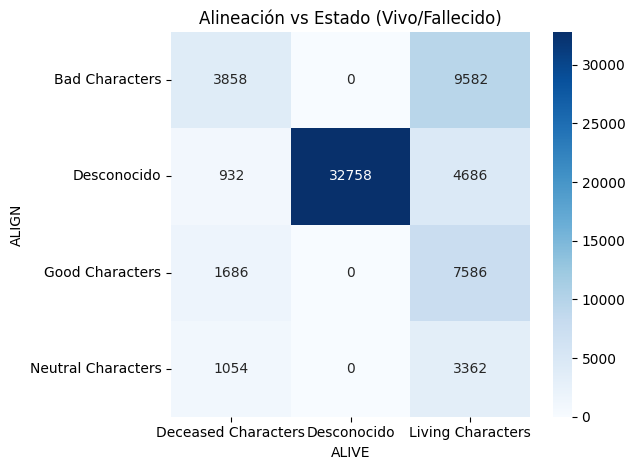

In [51]:
import seaborn as sns

tabla = pd.crosstab(df["ALIGN"], df["ALIVE"])

sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues")
plt.title("Alineación vs Estado (Vivo/Fallecido)")
plt.tight_layout()
plt.show()

### EJERCICIO 3. Histograma: Distribución del número de creación de personajes por décadas

- Analiza cómo se distribuyen la creación de los personas por décadas (Year).
- Crea un histograma cuantos personajes se crearon para cada década.


La mayor concentración de creación de personajes se da entre 1960 y 2000, con un pico notable en los 90. Las décadas anteriores a 1960 tienen muy pocos personajes.

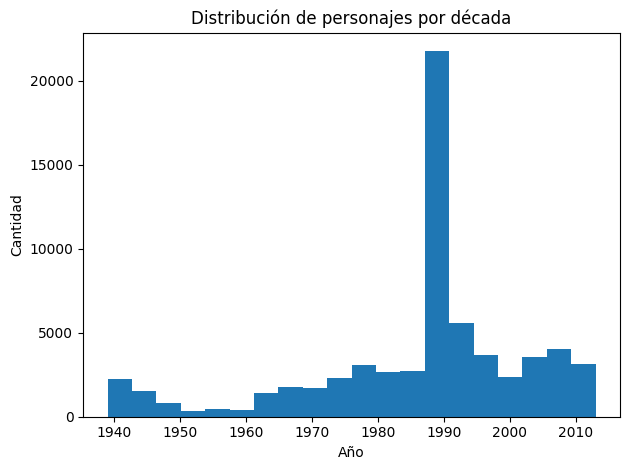

In [53]:
df["Year"].plot(kind="hist", bins=20)
plt.title("Distribución de personajes por década")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

### EJERCICIO 4. Crea 4 diagramas adicionales, diferentes a los ya usados en este deber e interpreta los resultados, cada uno deberia mostrar información relevante que considera el estudiante mostrar.

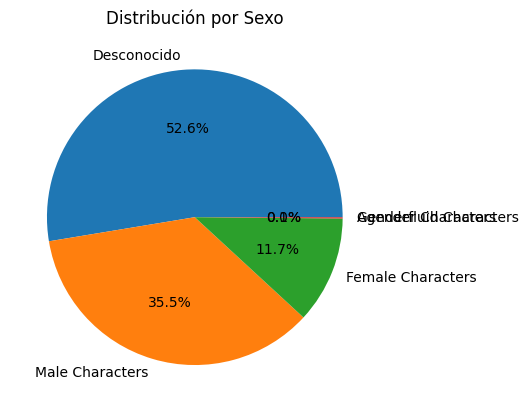

In [57]:
df["SEX"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribución por Sexo")
plt.ylabel("")
plt.show()

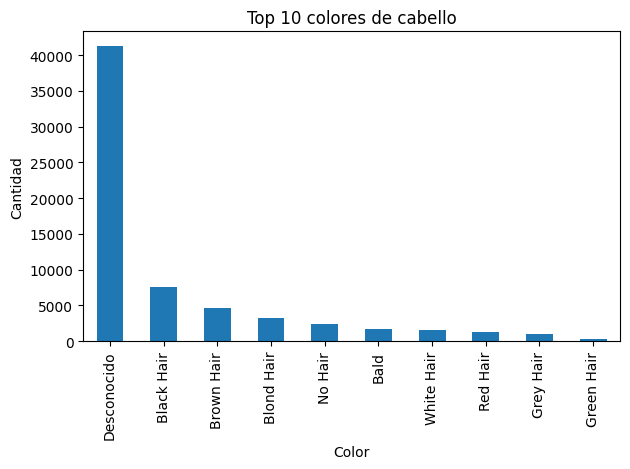

In [56]:
df["HAIR"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 colores de cabello")
plt.xlabel("Color")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

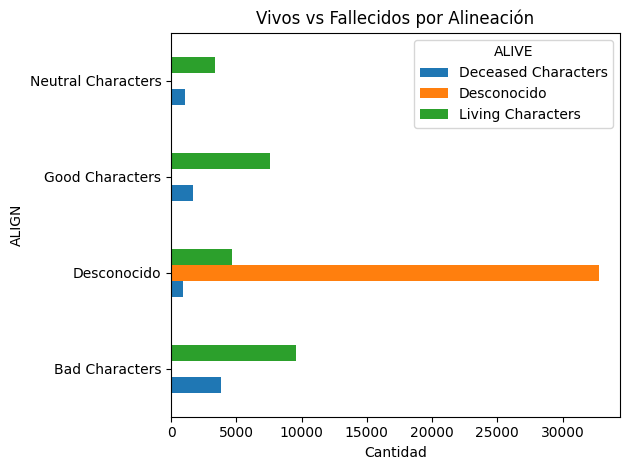

In [55]:
tabla = pd.crosstab(df["ALIGN"], df["ALIVE"])
tabla.plot(kind="barh")
plt.title("Vivos vs Fallecidos por Alineación")
plt.xlabel("Cantidad")
plt.tight_layout()
plt.show()

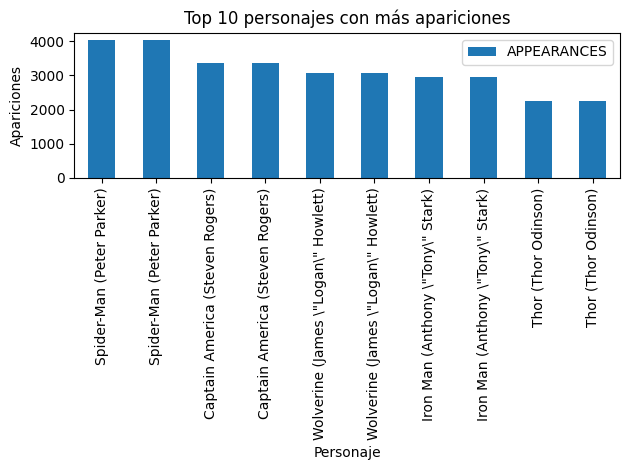

In [54]:
top10 = df.nlargest(10, "APPEARANCES")[["name", "APPEARANCES"]]
top10.plot(kind="bar", x="name", y="APPEARANCES")
plt.title("Top 10 personajes con más apariciones")
plt.xlabel("Personaje")
plt.ylabel("Apariciones")
plt.tight_layout()
plt.show()